# FEE/cosmic ratio reproduction, and fixing uncorrected crystals

Two things, per period:

1. **Reproduce Andrea's "FEE gain vs cosmic gain" ratio** using our own `output_iter<N>_p<period>/c<N>.txt` files (the FEE correction factor) and `coeff/cosmic.txt` (the cosmic gains), to compare against his published "NEW" values (p.73).
2. **Write corrected final gain files**: for crystals that never got a real FEE fit (their `c<N>.txt` entry is still the default `1.0000`, carried forward unchanged from iteration 1 because `analyzeFeePeak.C`'s fallback branch triggers whenever `MPV==-999` or the MC constant is `-999`), replace that `1.0000` with *this period's own computed ratio* before multiplying by the cosmic gain. Crystals that did get a real fit are left untouched.

The detection of "uncorrected" crystals relies on the c-factor being exactly `1.0000` in the last iteration -- that's the fallback's actual signature in the code (`prevC` never updates for a crystal whose fit keeps failing), not an approximation.

---
**This is the row-exclusion variant.** Andrea's slides (pp.34/61/76, golden period's 4th iteration only): *"I decided to remove Y=-5 and Y=5, and Y=-1 and Y=1: peaks were not well visible."* Checking showed the same ~35-41-crystal contamination (out of 166 total in those rows) sits in every period at similar magnitude, not just golden -- so this variant applies the exclusion to all six periods and writes to a separate `final_gains_rowexcl/` directory, keeping the original `fee_cosmic_ratio_and_gain_fix.ipynb` / `final_gains/` untouched for comparison.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

BASE_DIR = "/home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz"
COSMIC_FILE = os.path.join(BASE_DIR, "coeff", "cosmic.txt")
OUTPUT_DIR = os.path.join(BASE_DIR, "final_gains_rowexcl")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "plots"), exist_ok=True)

# Last completed iteration to use, per period.
LAST_ITER = {1: 4, 2: 4, 3: 4, 4: 4, 5: 4, 6: 4}

# Known-bad crystals (by DB channel id) -- zeroed out in the output gain files
# regardless of whether they were fitted or stuck. 153, 198, 275, 334 overlap with
# the hardcoded 2021 bad-channel list in IterateGainFactorDriver.java (which never
# actually applies to our 2019 work, since it only activates for calibYear==2021)
# 267 is not in that list, so this is a distinct, 2019-specific set.
ZERO_CHANNELS = {153, 198, 267, 275, 334}

# Rows iy in {-5,-1,1,5} -- Andrea (golden period 4th iteration): "I decided to
# remove Y=-5 and Y=5, and Y=-1 and Y=1: peaks were not well visible." iy=+-1 sit right
# next to the beam hole, iy=+-5 are the outermost rows -- both structurally prone to bad
# peaks regardless of period. Loaded from the id<->(ix,iy) map (util/crystal_id_to_ixiy_map.csv).
# Excluded from the ratio/histogram computation like ZERO_CHANNELS, but -- unlike
# ZERO_CHANNELS -- NOT hard-zeroed in the output: they fall back to the ratio, same as any
# other unfit crystal, since these are otherwise perfectly normal, non-dead crystals.
import csv
with open(os.path.join(BASE_DIR, "util", "crystal_id_to_ixiy_map.csv")) as f:
    ROW_EXCLUDE_IDS = {int(row["dbid"]) for row in csv.DictReader(f) if int(row["iy"]) in (-5, -1, 1, 5)}
print(f"ROW_EXCLUDE_IDS: {len(ROW_EXCLUDE_IDS)} crystals")

# Andrea's own published "NEW" (post (-13,-4) bug-fix) ratios, p.73,
# for comparison only -- not used in the correction itself.
ANDREA_RATIO = {1: 0.9201, 2: 0.9589, 3: 0.866, 4: 0.902, 5: 0.867, 6: 0.904}

ALL_PERIODS = [1, 2, 3, 4, 5, 6]
PERIODS = [p for p in ALL_PERIODS
           if os.path.exists(os.path.join(BASE_DIR, f"output_iter{LAST_ITER[p]}_p{p}", f"c{LAST_ITER[p]}.txt"))]
print(f"Periods with iteration-4 data available: {PERIODS}"
      + (f"  (skipping {sorted(set(ALL_PERIODS)-set(PERIODS))}, not ready yet)" if len(PERIODS) < len(ALL_PERIODS) else ""))
STUCK_VALUE = 1.0
TOL = 1e-6

ROW_EXCLUDE_IDS: 166 crystals
Periods with iteration-4 data available: [1, 2, 3, 4, 5, 6]


In [2]:
def read_gain_file(path):
    """Read a headerless 'channel_id,value' CSV (cosmic.txt / c<N>.txt format) into a {id: value} dict."""
    d = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            cid, val = line.split(",")
            d[int(cid)] = float(val)
    return d

cosmic = read_gain_file(COSMIC_FILE)
print(f"Loaded {len(cosmic)} cosmic gains from {COSMIC_FILE}")

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def fit_gaussian_mean(values, bins=30):
    """Bin `values` and fit a Gaussian. Returns (mu, mu_err, sigma, popt),
    or (None, None, None, None) if the fit doesn't converge."""
    counts, edges = np.histogram(values, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])
    mask = counts > 0
    p0 = [counts.max(), float(np.mean(values)), float(np.std(values))]
    try:
        popt, pcov = curve_fit(gaussian, centers[mask], counts[mask], p0=p0, maxfev=10000)
        perr = np.sqrt(np.diag(pcov))
        return popt[1], perr[1], abs(popt[2]), popt
    except RuntimeError:
        return None, None, None, None

Loaded 442 cosmic gains from /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/coeff/cosmic.txt


## Step 1: compute our own ratio per period, and compare to Andrea's

In [3]:
results = {}
for p in PERIODS:
    it = LAST_ITER[p]
    cfile = os.path.join(BASE_DIR, f"output_iter{it}_p{p}", f"c{it}.txt")
    if not os.path.exists(cfile):
        print(f"WARNING: period {p} -- {cfile} not found, skipping")
        continue
    c = read_gain_file(cfile)

    # Known-bad crystals excluded up front -- some of them (153, 198, 275, and
    # 334 in period 6) actually have a real, non-1.0000 fit value, but it's a
    # spurious outlier (why they're flagged bad in the first place), so they must
    # not contaminate the ratio average or the histograms either -- not just get
    # zeroed in the final output file.
    c_usable = {cid: v for cid, v in c.items() if cid not in ZERO_CHANNELS and cid not in ROW_EXCLUDE_IDS}

    # crystals with a genuine FEE fit vs. ones that never moved off the
    # iteration-1 default of 1.0000 (analyzeFeePeak.C's fallback branch)
    fitted = {cid: v for cid, v in c_usable.items() if abs(v - STUCK_VALUE) > TOL}
    stuck = {cid: v for cid, v in c_usable.items() if abs(v - STUCK_VALUE) <= TOL}
    row_excluded = {cid: v for cid, v in c.items() if cid in ROW_EXCLUDE_IDS and cid not in ZERO_CHANNELS}

    fitted_vals = list(fitted.values())
    simple_mean = float(np.mean(fitted_vals))
    simple_std = float(np.std(fitted_vals))

    fit_mu, fit_mu_err, fit_sigma, gauss_popt = fit_gaussian_mean(fitted_vals)
    if fit_mu is None:
        print(f"Period {p}: Gaussian fit did not converge, falling back to simple mean")
        my_ratio, my_ratio_err = simple_mean, simple_std
        gauss_popt = None
    else:
        my_ratio, my_ratio_err = fit_mu, fit_mu_err

    results[p] = {
        "iter_used": it,
        "c_values": c,
        "fitted_ids": set(fitted.keys()),
        "stuck_ids": set(stuck.keys()),
        "row_excluded_ids": set(row_excluded.keys()),
        "my_ratio": my_ratio,          # Gaussian-fit mu (or simple-mean fallback)
        "my_ratio_err": my_ratio_err,  # fit uncertainty on mu (or simple std as fallback)
        "gauss_sigma": fit_sigma,
        "gauss_popt": gauss_popt,      # for overlaying the fitted curve on the histogram later
        "simple_mean": simple_mean,    # kept for comparison/sanity-check only, not used downstream
        "simple_std": simple_std,
    }

    print(f"Period {p} (iter {it}): {len(fitted)} fitted / {len(stuck)} stuck at 1.0000 / "
          f"{len(row_excluded)} row-excluded "
          f"-- Gaussian mu = {my_ratio:.4f} +/- {my_ratio_err:.4f} "
          f"(simple mean = {simple_mean:.4f} +/- {simple_std:.4f}, "
          f"Andrea's NEW = {ANDREA_RATIO[p]})")

Period 1 (iter 4): 124 fitted / 148 stuck at 1.0000 / 165 row-excluded -- Gaussian mu = 0.9518 +/- 0.0057 (simple mean = 0.9612 +/- 0.0500, Andrea's NEW = 0.9201)
Period 2 (iter 4): 96 fitted / 176 stuck at 1.0000 / 165 row-excluded -- Gaussian mu = 0.9759 +/- 0.0033 (simple mean = 0.9988 +/- 0.0541, Andrea's NEW = 0.9589)
Period 3 (iter 4): 113 fitted / 159 stuck at 1.0000 / 165 row-excluded -- Gaussian mu = 0.8986 +/- 0.0076 (simple mean = 0.9120 +/- 0.0468, Andrea's NEW = 0.866)
Period 4 (iter 4): 91 fitted / 181 stuck at 1.0000 / 165 row-excluded -- Gaussian mu = 0.9288 +/- 0.0062 (simple mean = 0.9406 +/- 0.0476, Andrea's NEW = 0.902)
Period 5 (iter 4): 96 fitted / 176 stuck at 1.0000 / 165 row-excluded -- Gaussian mu = 0.8940 +/- 0.0065 (simple mean = 0.9072 +/- 0.0459, Andrea's NEW = 0.867)
Period 6 (iter 4): 179 fitted / 93 stuck at 1.0000 / 165 row-excluded -- Gaussian mu = 0.9475 +/- 0.0047 (simple mean = 0.9524 +/- 0.0507, Andrea's NEW = 0.904)


In [4]:
comparison = pd.DataFrame({
    "period": PERIODS,
    "iter_used": [results[p]["iter_used"] for p in PERIODS],
    "n_fitted": [len(results[p]["fitted_ids"]) for p in PERIODS],
    "n_stuck": [len(results[p]["stuck_ids"]) for p in PERIODS],
    "n_row_excluded": [len(results[p]["row_excluded_ids"]) for p in PERIODS],
    "my_ratio": [results[p]["my_ratio"] for p in PERIODS],           # Gaussian-fit mu
    "my_ratio_err": [results[p]["my_ratio_err"] for p in PERIODS],   # fit uncertainty on mu
    "gauss_sigma": [results[p]["gauss_sigma"] for p in PERIODS],
    "simple_mean": [results[p]["simple_mean"] for p in PERIODS],     # sanity-check comparison only
    "andrea_ratio": [ANDREA_RATIO[p] for p in PERIODS],
})
comparison["diff"] = comparison["my_ratio"] - comparison["andrea_ratio"]
comparison["pct_diff"] = 100 * comparison["diff"] / comparison["andrea_ratio"]
comparison

,period,iter_used,n_fitted,n_stuck,n_row_excluded,my_ratio,my_ratio_err,gauss_sigma,simple_mean,andrea_ratio,diff,pct_diff
0,1,4,124,148,165,0.951824,0.005662,0.045707,0.961175,0.9201,0.031724,3.447910
1,2,4,96,176,165,0.975921,0.003281,0.025434,0.998794,0.9589,0.017021,1.775106
2,3,4,113,159,165,0.898633,0.007569,0.052296,0.912042,0.8660,0.032633,3.768204
3,4,4,91,181,165,0.928770,0.006226,0.048405,0.940614,0.9020,0.026770,2.967872
4,5,4,96,176,165,0.894030,0.006465,0.046524,0.907234,0.8670,0.027030,3.117688
5,6,4,179,93,165,0.947537,0.004706,0.055052,0.952439,0.9040,0.043537,4.816028


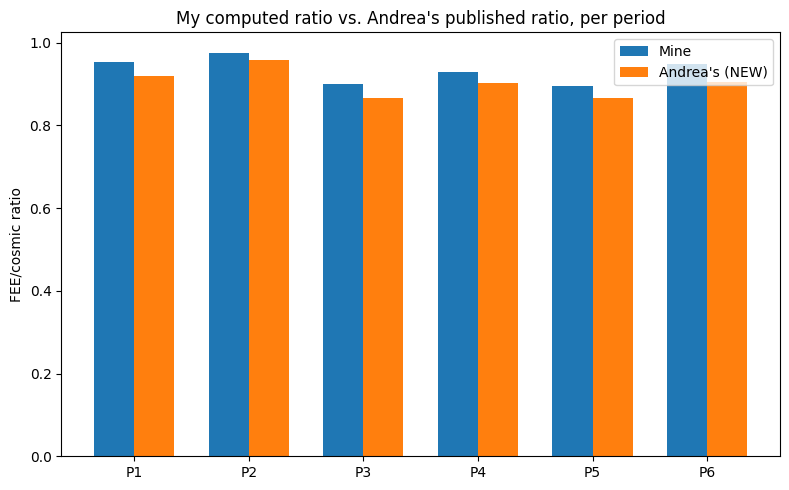

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(PERIODS))
width = 0.35
ax.bar(x - width/2, comparison["my_ratio"], width, label="Mine")
ax.bar(x + width/2, comparison["andrea_ratio"], width, label="Andrea's (NEW)")
ax.set_xticks(x)
ax.set_xticklabels([f"P{p}" for p in PERIODS])
ax.set_ylabel("FEE/cosmic ratio")
ax.set_title("My computed ratio vs. Andrea's published ratio, per period")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "plots", "ratio_comparison_all_periods.png"), dpi=150)
plt.show()

## Per-period FEE correction-factor distributions

One PNG per period: histogram of the `c<N>.txt` values among crystals that got a real FEE fit (i.e. excluding the ones stuck at `1.0000`), with vertical lines marking `my_ratio` and `ANDREA_RATIO[p]` -- both fallback candidates used for the stuck crystals in Step 2, shown against the actual distribution they're each meant to represent the average of.

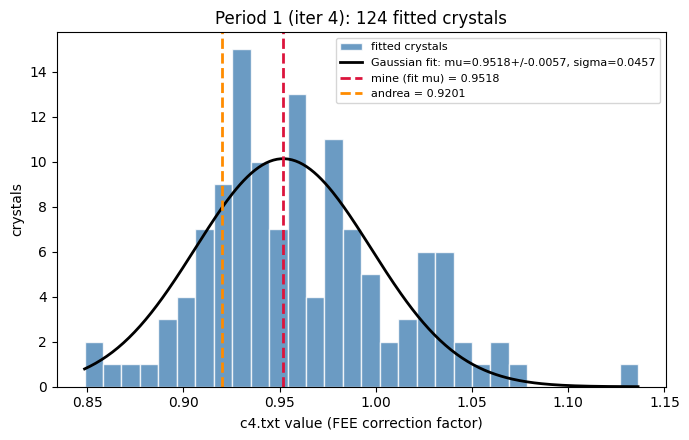

Period 1: saved /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/plots/period_p1_fee_ratio_hist.png


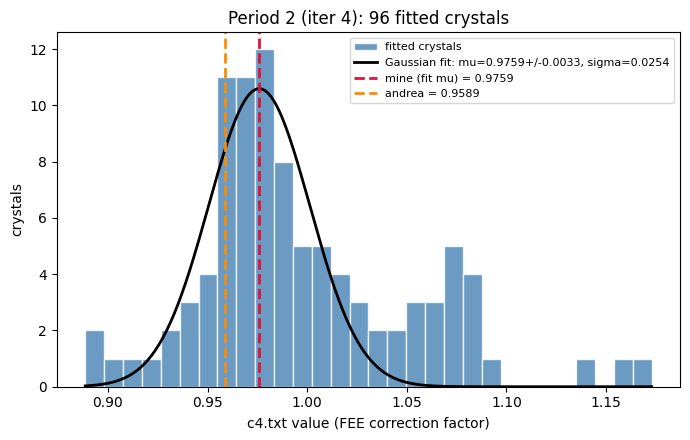

Period 2: saved /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/plots/period_p2_fee_ratio_hist.png


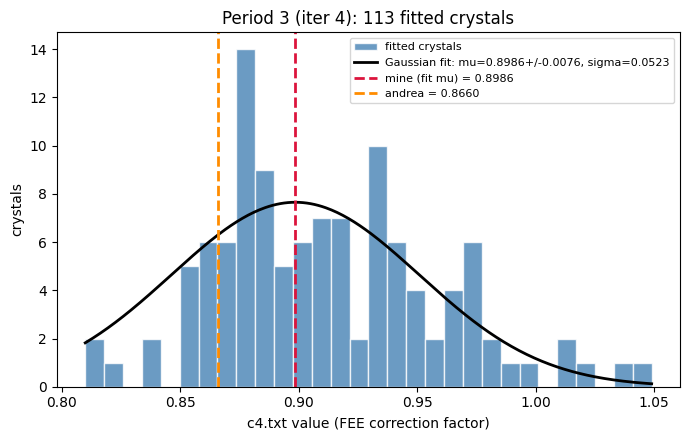

Period 3: saved /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/plots/period_p3_fee_ratio_hist.png


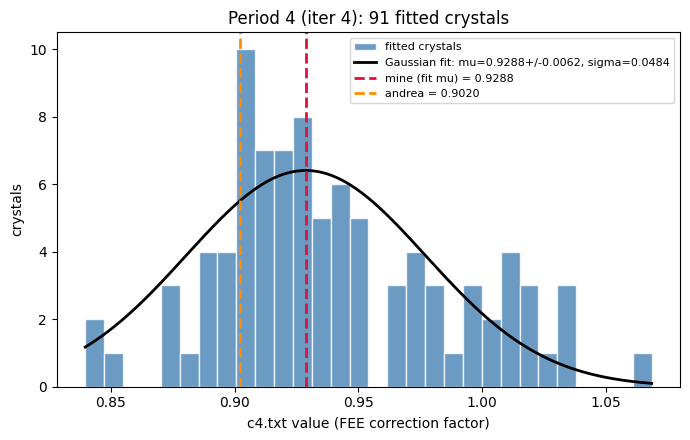

Period 4: saved /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/plots/period_p4_fee_ratio_hist.png


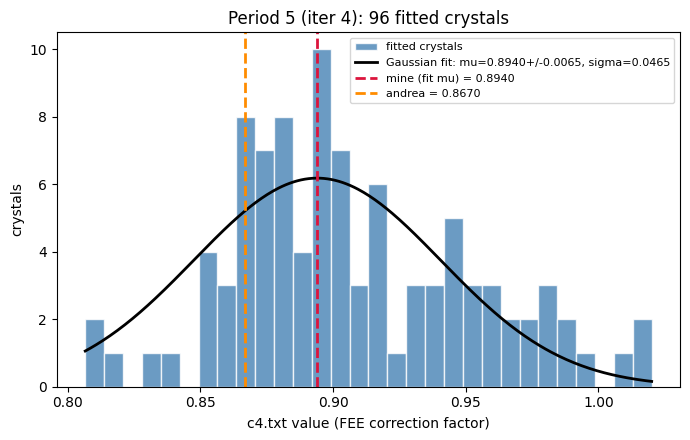

Period 5: saved /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/plots/period_p5_fee_ratio_hist.png


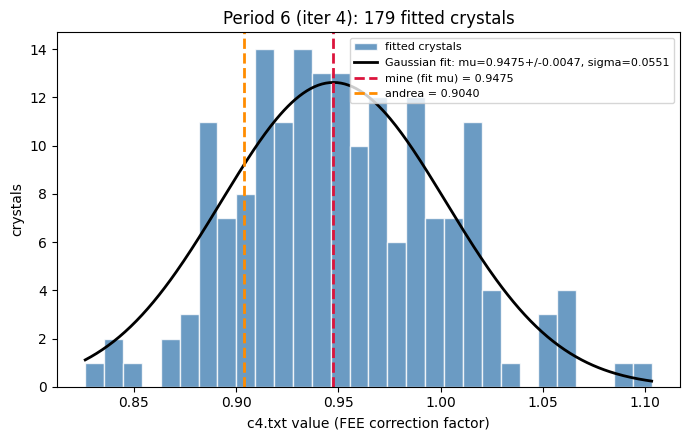

Period 6: saved /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/plots/period_p6_fee_ratio_hist.png


In [6]:
for p in PERIODS:
    if p not in results:
        continue
    r = results[p]
    fitted_vals = list({cid: v for cid, v in r["c_values"].items() if cid in r["fitted_ids"]}.values())

    fig, ax = plt.subplots(figsize=(7, 4.5))
    counts, edges, _ = ax.hist(fitted_vals, bins=30, color="steelblue", alpha=0.8, edgecolor="white",
                                label="fitted crystals")

    if r["gauss_popt"] is not None:
        xx = np.linspace(edges[0], edges[-1], 300)
        ax.plot(xx, gaussian(xx, *r["gauss_popt"]), color="black", linewidth=2,
                label=f'Gaussian fit: mu={r["my_ratio"]:.4f}+/-{r["my_ratio_err"]:.4f}, sigma={r["gauss_sigma"]:.4f}')

    ax.axvline(r["my_ratio"], color="crimson", linestyle="--", linewidth=2,
               label=f'mine (fit mu) = {r["my_ratio"]:.4f}')
    ax.axvline(ANDREA_RATIO[p], color="darkorange", linestyle="--", linewidth=2,
               label=f'andrea = {ANDREA_RATIO[p]:.4f}')
    ax.set_xlabel(f"c{r['iter_used']}.txt value (FEE correction factor)")
    ax.set_ylabel("crystals")
    ax.set_title(f"Period {p} (iter {r['iter_used']}): "
                 f"{len(fitted_vals)} fitted crystals")
    ax.legend(fontsize=8)
    plt.tight_layout()

    out_png = os.path.join(OUTPUT_DIR, "plots", f"period_p{p}_fee_ratio_hist.png")
    fig.savefig(out_png, dpi=150)
    plt.show()
    print(f"Period {p}: saved {out_png}")

## Step 2: write corrected gain files

For each period, per crystal:
- if it got a real FEE fit: keep its own `c<N>.txt` value unchanged
- if it's stuck at `1.0000`: replace with a fallback ratio -- computed **two ways**, written as separate output variants so they can be compared directly:
  - **mine**: this period's own `my_ratio` (computed in Step 1, from our own files)
  - **andrea**: Andrea's published ratio for that period (`ANDREA_RATIO`, p.73)

Four files per period:
- `corrected_c<N>_p<period>_myratio.txt` / `_andrearatio.txt` -- the corrected multiplicative factor, same format as `c<N>.txt` (feed either to `IterateGainFactorDriver` as a finished `ecalGains.txt`)
- `final_gain_p<period>_myratio.txt` / `_andrearatio.txt` -- the absolute gain, `cosmic * corrected_c`, in `channel_id,gain` format matching the DB-upload convention

In [ ]:
for p in PERIODS:
    if p not in results:
        continue
    r = results[p]
    it = r["iter_used"]

    for label, ratio in [("myratio", r["my_ratio"]), ("andrearatio", ANDREA_RATIO[p])]:
        corrected_c = {}
        final_gain = {}
        for cid, c_val in r["c_values"].items():
            if cid in r["stuck_ids"] or cid in r["row_excluded_ids"]:
                c_val = ratio  # replace the uncorrected 1.0000, or override an unreliable row-crystal fit
            corrected_c[cid] = c_val
            final_gain[cid] = cosmic[cid] * c_val
            if cid in ZERO_CHANNELS:  # known-bad crystal -- zero regardless of fit status
                corrected_c[cid] = 0.0
                final_gain[cid] = 0.0

        c_out = os.path.join(OUTPUT_DIR, f"corrected_c{it}_p{p}_{label}.txt")
        g_out = os.path.join(OUTPUT_DIR, f"final_gain_p{p}_{label}.txt")

        with open(c_out, "w") as f:
            for cid in sorted(corrected_c):
                f.write(f"{cid},{corrected_c[cid]:.4f}\n")

        with open(g_out, "w") as f:
            for cid in sorted(final_gain):
                f.write(f"{cid},{final_gain[cid]:.6f}\n")

        print(f"Period {p} [{label}]: wrote {c_out} and {g_out} "
              f"({len(r['stuck_ids'])} stuck + {len(r['row_excluded_ids'])} row-excluded "
              f"-> {ratio:.4f})")

Period 1 [myratio]: wrote /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/corrected_c4_p1_myratio.txt and /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/final_gain_p1_myratio.txt (148 stuck + 165 row-excluded -> 0.9518)
Period 1 [andrearatio]: wrote /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/corrected_c4_p1_andrearatio.txt and /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/final_gain_p1_andrearatio.txt (148 stuck + 165 row-excluded -> 0.9201)
Period 2 [myratio]: wrote /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/corrected_c4_p2_myratio.txt and /home/ekhan/andrea_hps_code_branch_2019/HPS-CODE/CALIBRATION/FEE-Erbaz/final_gains_rowexcl/final_gain_p2_myratio.txt (176 stuck + 165 row-excluded -> 0.9759)
Period 2 [andrearatio]: wrote /home/ekhan/andrea_hps_code_branch_20